## Lab 2

### Part 3. Poetry generation

Let's try to generate some poetry using RNNs. 

You have several choices here: 

* The Shakespeare sonnets, file `sonnets.txt` available in the notebook directory.

* Роман в стихах "Евгений Онегин" Александра Сергеевича Пушкина. В предобработанном виде доступен по [ссылке](https://github.com/attatrol/data_sources/blob/master/onegin.txt).

* Some other text source, if it will be approved by the course staff.

Text generation can be designed in several steps:
    
1. Data loading.
2. Dictionary generation.
3. Data preprocessing.
4. Model (neural network) training.
5. Text generation (model evaluation).


In [2]:
import string
import torch
import os

### Data loading: Shakespeare

Shakespeare sonnets are awailable at this [link](http://www.gutenberg.org/ebooks/1041?msg=welcome_stranger). In addition, they are stored in the same directory as this notebook (`sonnetes.txt`). Simple preprocessing is already done for you in the next cell: all technical info is dropped.

In [3]:
if not os.path.exists('sonnets.txt'):
    !wget https://raw.githubusercontent.com/girafe-ai/ml-course/22f_basic/homeworks/lab02_deep_learning/sonnets.txt

with open('sonnets.txt', 'r') as iofile:
    text = iofile.readlines()
    
TEXT_START = 45
TEXT_END = -368
text = text[TEXT_START : TEXT_END]
assert len(text) == 2616

In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [4]:
text = ''.join(text).lower()

assert len(text) == 100225, 'Are you sure you have concatenated all the strings?'
assert not any([x in set(text) for x in string.ascii_uppercase]), 'Uppercase letters are present'
print('OK!')

OK!


### Data loading: "Евгений Онегин"


In [5]:
!wget https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
    
with open('onegin.txt', 'r') as iofile:
    text = iofile.readlines()
    
text = [x.replace('\t\t', '') for x in text]

--2024-11-17 18:41:40--  https://raw.githubusercontent.com/attatrol/data_sources/master/onegin.txt
Распознаётся raw.githubusercontent.com (raw.githubusercontent.com)… 185.199.108.133, 185.199.111.133, 185.199.109.133, ...
Подключение к raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 262521 (256K) [text/plain]
Сохранение в: ‘onegin.txt.5’

onegin.txt.5        100%[===================>] 256,37K  --.-KB/s    за 0,09s   

2024-11-17 18:41:41 (2,69 MB/s) - ‘onegin.txt.5’ сохранён [262521/262521]



In opposite to the in-class practice, this time we want to predict complex text. Let's reduce the complexity of the task and lowercase all the symbols.

Now variable `text` is a list of strings. Join all the strings into one and lowercase it.

In [6]:
text = ''.join(text).lower()

Put all the characters, that you've seen in the text, into variable `tokens`.

In [7]:
tokens = sorted(set(text))

Create dictionary `token_to_idx = {<char>: <index>}` and dictionary `idx_to_token = {<index>: <char>}`

In [11]:
token_to_idx = {t: i for i, t in enumerate(tokens)}
idx_to_token = {i: t for i, t in enumerate(tokens)}
print(token_to_idx)
print(idx_to_token)

{'\n': 0, ' ': 1, '!': 2, '(': 3, ')': 4, ',': 5, '-': 6, '.': 7, '5': 8, '7': 9, '8': 10, '9': 11, ':': 12, ';': 13, '?': 14, '[': 15, ']': 16, '^': 17, 'a': 18, 'b': 19, 'c': 20, 'd': 21, 'e': 22, 'f': 23, 'g': 24, 'h': 25, 'i': 26, 'k': 27, 'l': 28, 'm': 29, 'n': 30, 'o': 31, 'p': 32, 'q': 33, 'r': 34, 's': 35, 't': 36, 'u': 37, 'v': 38, 'w': 39, 'x': 40, 'y': 41, 'z': 42, '«': 43, '»': 44, 'а': 45, 'б': 46, 'в': 47, 'г': 48, 'д': 49, 'е': 50, 'ж': 51, 'з': 52, 'и': 53, 'й': 54, 'к': 55, 'л': 56, 'м': 57, 'н': 58, 'о': 59, 'п': 60, 'р': 61, 'с': 62, 'т': 63, 'у': 64, 'ф': 65, 'х': 66, 'ц': 67, 'ч': 68, 'ш': 69, 'щ': 70, 'ъ': 71, 'ы': 72, 'ь': 73, 'э': 74, 'ю': 75, 'я': 76, 'ё': 77, '–': 78, '—': 79, '’': 80, '…': 81, '€': 82}
{0: '\n', 1: ' ', 2: '!', 3: '(', 4: ')', 5: ',', 6: '-', 7: '.', 8: '5', 9: '7', 10: '8', 11: '9', 12: ':', 13: ';', 14: '?', 15: '[', 16: ']', 17: '^', 18: 'a', 19: 'b', 20: 'c', 21: 'd', 22: 'e', 23: 'f', 24: 'g', 25: 'h', 26: 'i', 27: 'k', 28: 'l', 29: 'm',

In [10]:
targets = torch.tensor([token_to_idx[t] for t in text])
idxs = torch.nn.functional.one_hot(targets).to(torch.float32)
print(targets)


tensor([ 0, 26,  0,  ..., 57,  7,  0])


### Building the model

Now we want to build and train recurrent neural net which would be able to something similar to Shakespeare's poetry.

Let's use vanilla RNN, similar to the one created during the lesson.

In [12]:
torch.backends.cudnn.enabled = False

In [13]:
from torch.nn.functional import softmax, log_softmax
class M_RNN(torch.nn.Module):
    def __init__(self, hidden_size, in_dim, ou_dim):
        super().__init__()
        self.rnn = RNN(in_dim, hidden_size, num_layers=5, nonlinearity='tanh',  dropout=0.2, bias=True)
        self.mlp =  Linear(hidden_size, ou_dim)
        
    def forward(self, x):
        return log_softmax(self.mlp(self.rnn(x)[0]), 1)

In [18]:
from torch.nn import RNN, LSTM, Linear, NLLLoss, CrossEntropyLoss
import torch 
#device = torch.device('cuda')
m_rnn = M_RNN(1024, len(token_to_idx), len(token_to_idx))
# m_lstm = M_LSTM(1024, len(token_to_idx), len(token_to_idx)).to(device)
loss_func = NLLLoss(reduction='sum')
#idxs = idxs.to(device)
#targets = targets.to(device)

In [19]:
from tqdm import tqdm
def train(model, optimizer, epochs):
    losses = []
    
    for epoch in tqdm(range(epochs)):
        model.train()
        for i in range(0, len(targets), 256):
            optimizer.zero_grad()
            result= model(idxs[i:i+256])
#             i_min = min(i+1, len(targets))
#             i_max = min(len(targets), i+257)
            loss = loss_func(result[:-1, :], targets[i+1: i+256])
            loss.backward()
            optimizer.step()
            
        model.eval()
        with torch.no_grad():
            result= model(idxs)
            loss = loss_func(result[:-1, :], targets[1:])
            losses.append(loss.item())
    return losses

In [20]:
opt = torch.optim.Adam(m_rnn.parameters(), lr=1e-4, amsgrad=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, 100, 1)
l_rnn = train(m_rnn, opt, 15)

  7%|██▍                                  | 1/15 [2:26:58<34:17:40, 8818.64s/it]


KeyboardInterrupt: 

Plot the loss function (axis X: number of epochs, axis Y: loss function).

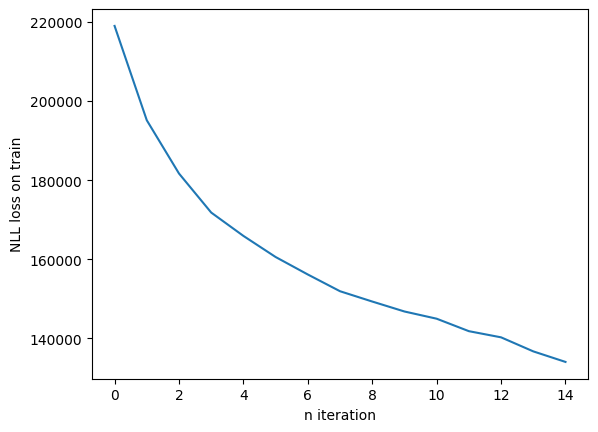

In [15]:
import matplotlib.pyplot as plt
plt.plot(l_rnn)
plt.xlabel("n iteration")
plt.ylabel("NLL loss on train")
plt.show()

In [16]:
torch.save(m_rnn, '/kaggle/working/m_rnn')

In [17]:
MAX_LENGTH = 256

In [18]:
import numpy as np
def generate_sample(char_rnn, mlp, seed_phrase=' Hello', max_length=MAX_LENGTH, temperature=1.0, device=None):
    '''
    ### Disclaimer: this is an example function for text generation.
    ### You can either adapt it in your code or create your own function
    
    The function generates text given a phrase of length at least SEQ_LENGTH.
    :param seed_phrase: prefix characters. The RNN is asked to continue the phrase
    :param max_length: maximum output length, including seed_phrase
    :param temperature: coefficient for sampling.  higher temperature produces more chaotic outputs, 
        smaller temperature converges to the single most likely output.
        
    Be careful with the model output. This model waits logits (not probabilities/log-probabilities)
    of the next symbol.
    '''
    out_sequence = torch.tensor([[token_to_idx[t]] for t in seed_phrase])
#     print(out_sequence.shape)
    
    out, hid_state = char_rnn(torch.nn.functional.one_hot(out_sequence[:, 0], 38).to(torch.float32).to(device))
    
#     print(out.shape, hid_state.shape)
    #start generating
    for _ in range(max_length - len(seed_phrase)):
#         print(out_sequence.shape, hid_state.shape)
        out, hid_state = char_rnn(torch.nn.functional.one_hot(out_sequence[-1], 38).to(torch.float32).to(device), hid_state)
        # Be really careful here with the model output
        p_next = softmax(mlp(out) / temperature, dim=-1).data.cpu().numpy()[0]
        
        # sample next token and push it back into x_sequence
#         print(p_next.shape, len(tokens))
        next_ix = np.random.choice(len(tokens), p=p_next)
        next_ix = torch.tensor([[next_ix]], dtype=torch.int64)
#         print(out_sequence.shape, next_ix.shape)
        out_sequence = torch.cat([out_sequence, next_ix], dim=0)
    return ''.join([idx_to_token[ix[0]] for ix in out_sequence.data.numpy()])

In [19]:
# An example of generated text.
m_rnn.eval()
print(generate_sample(m_rnn.rnn, m_rnn.mlp, seed_phrase='hide my will in thine?', device=device))

hide my will in thine?
  but sweetlescfite;
  what feol lave where is thy glayst jeor;
  a devitith on my madiins of a pade'st of herse

  cliii

  lyich 'tall of blore the remance tuul for three,
    our remins in my braves what i thy love blest,
  or mow


### More poetic model

Let's use LSTM instead of vanilla RNN and compare the results.

Plot the loss function of the number of epochs. Does the final loss become better?

In [20]:
from torch.nn.functional import softmax, log_softmax
class M_LSTM(torch.nn.Module):
    def __init__(self, hidden_size, in_dim, ou_dim):
        super().__init__()
        self.lstm = LSTM(in_dim, hidden_size, num_layers=5, dropout=0.2, bias=True)
        self.mlp =  Linear(hidden_size, ou_dim)
        
    def forward(self, x):
        return log_softmax(self.mlp(self.lstm(x)[0]), 1)

In [21]:
from torch.nn import RNN, LSTM, Linear, NLLLoss, CrossEntropyLoss
import torch 
device = torch.device('cuda')
m_lstm = M_LSTM(1024, len(token_to_idx), len(token_to_idx)).to(device)
loss_func = NLLLoss(reduction='sum')
idxs = idxs.to(device)
targets = targets.to(device)

In [22]:
opt = torch.optim.Adam(m_lstm.parameters(), lr=1e-4, amsgrad=True)
scheduler = torch.optim.lr_scheduler.CosineAnnealingWarmRestarts(opt, 100, 1)
l_lstm = train(m_lstm, opt, 15)

100%|██████████| 15/15 [1:20:48<00:00, 323.23s/it]


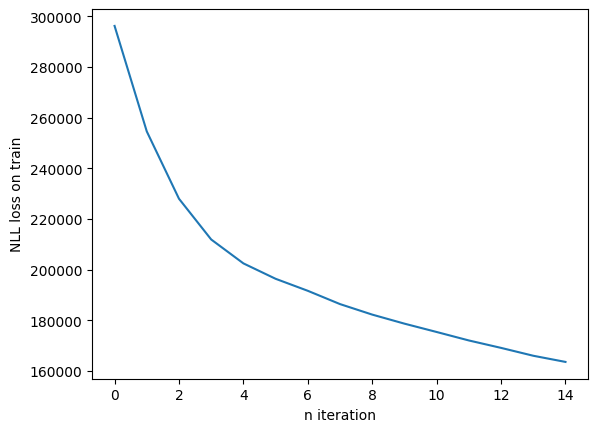

In [23]:
import matplotlib.pyplot as plt
plt.plot(l_lstm)
plt.xlabel("n iteration")
plt.ylabel("NLL loss on train")
plt.show()

In [24]:
torch.save(m_lstm, '/kaggle/working/m_lstm')

Generate text using the trained net with different `temperature` parameter: `[0.1, 0.2, 0.5, 1.0, 2.0]`.

Evaluate the results visually, try to interpret them.

In [28]:
m_lstm.eval()
for t in [0.1, 0.2, 0.5, 1.0, 2.0]:
    prase = generate_sample(m_lstm.lstm, m_lstm.mlp, seed_phrase='hide my will in thine?', device=device, temperature=t)
    print(f'Temperature {t}: \n{prase}\n')

Temperature 0.1: 
hide my will in thine?      not the world the world the sould and me.

  cxiii

  the worth the world in the world and meart,
  and thou art thou art that i have thee me.

  cxliii

  the world the sore when the worth the worth thee thee,
    and the world

Temperature 0.2: 
hide my will in thine?    no not thou art the worth and thee thee,
  the parse is thy sonl the sould the some,
  and thou art the world of thee i am me,
    then i am the sore the trinke the worth thee thee,
    the sarse the seel the worth the sould of th

Temperature 0.5: 
hide my will in thine?    the forpore with fair me thee art re,
  when i have my live eyes for thou art nons,
  that thy so face the shome co dy gour for fried,
  and i sare thee, in my mnauty de san,
  that thou art that i have ov thy deseet,
  and thou b

Temperature 1.0: 
hide my will in thine? ov thy loveer thy prowing inporse,
    that mot site i not by hroadd thinc chow beds,
  and wardinc one thou ward old to bumt frowh

Чем выше температура тем более разннобразный и "хаотичный" текст начинают генерировать модели

### Saving and loading models

Save the model to the disk, then load it and generate text. Examples are available [here](https://pytorch.org/tutorials/beginner/saving_loading_models.html]).

In [4]:
torch.save(m_lstm, '/kaggle/working/m_lstm')
torch.save(m_rnn, '/kaggle/working/m_rnn')

In [31]:
model_test = torch.load("/kaggle/working/m_lstm", weights_only=False)
model_test.eval()

M_LSTM(
  (lstm): LSTM(38, 1024, num_layers=5, dropout=0.2)
  (mlp): Linear(in_features=1024, out_features=38, bias=True)
)

In [32]:
generate_sample(model_test.lstm, model_test.mlp, seed_phrase='hide my will in thine?', device=device, temperature=0.5)

'hide my will in thine?   the of thy soll the sarmer in thee mot dend\n  thou santher and the sland shall so defart,\n  ore faod should af oye, wo pave in me,\n  whe love that for her i shall the seurt feart,\n  or that whe frow thou sorst thy singe thee say ey'

### References
1. <a href='http://karpathy.github.io/2015/05/21/rnn-effectiveness/'> Andrew Karpathy blog post about RNN. </a> 
There are several examples of genration: Shakespeare texts, Latex formulas, Linux Sourse Code and children names.
2. <a href='https://github.com/karpathy/char-rnn'> Repo with char-rnn code </a>
3. Cool repo with PyTorch examples: [link](https://github.com/spro/practical-pytorch`)